In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("D:\\R V Pavan\\Projects\\PayGuard AI\\Dataset\\Raw_Data.csv")

### Understand the Dataset

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [8]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

### Exploratory Data Analysis (EDA)

Fraud Distribution Visualization

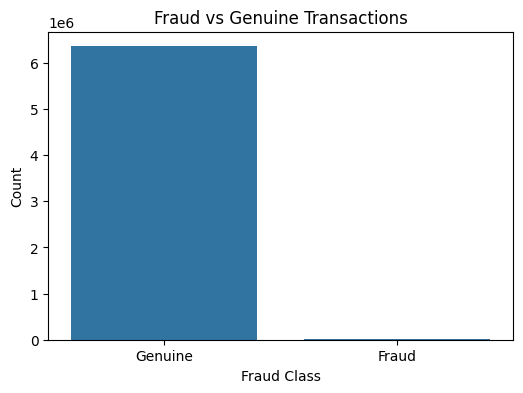

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='isFraud', data=df)

plt.xticks([0,1], ['Genuine', 'Fraud'])

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Fraud Class")
plt.ylabel("Count")

plt.show()

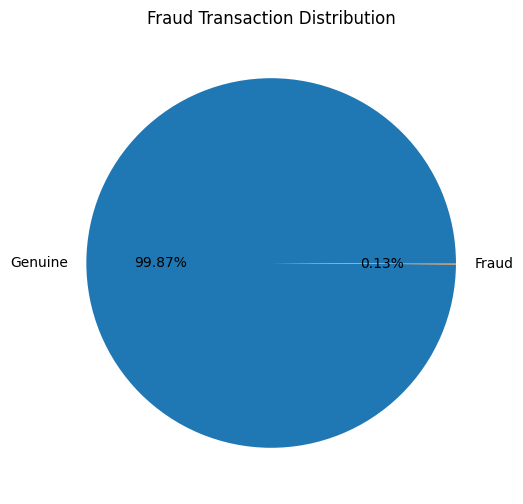

In [13]:
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=['Genuine', 'Fraud'],
    autopct='%1.2f%%'
)

plt.title("Fraud Transaction Distribution")

plt.show()

Fraud Analysis by Transaction Type

In [14]:
fraud_by_type = pd.crosstab(df['type'], df['isFraud'])

fraud_by_type

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


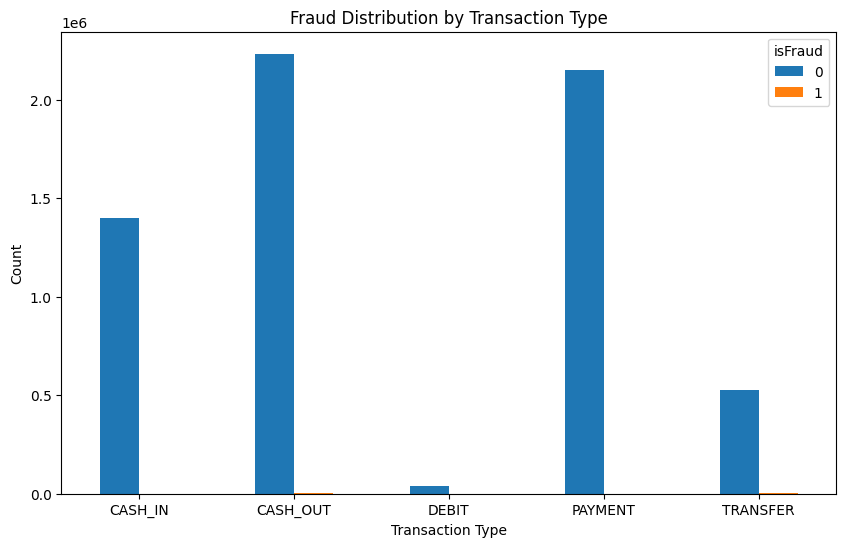

In [15]:
fraud_by_type.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Fraud Distribution by Transaction Type")

plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

Fraud Rate by Transaction Type (%) - Which transaction type is MOST risky proportionally

In [16]:
fraud_rate = df.groupby('type')['isFraud'].mean() * 100  # Fraud percentage for each transaction type

fraud_rate

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

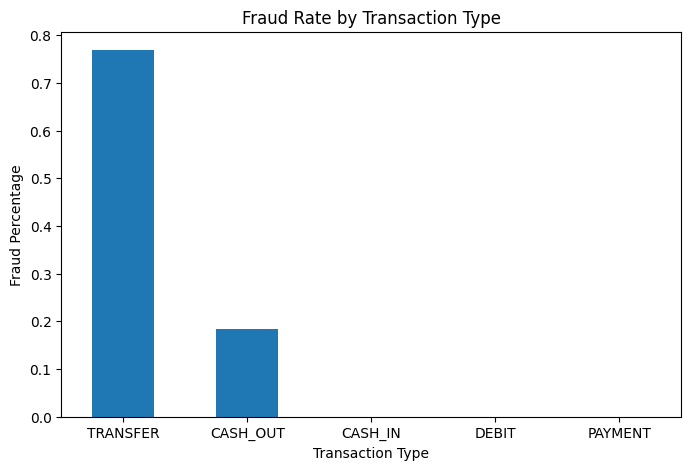

In [17]:
fraud_rate.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Percentage")

plt.xticks(rotation=0)

plt.show()

Analyze Fraud by Transaction Amount - Are fraudulent transactions unusually large?

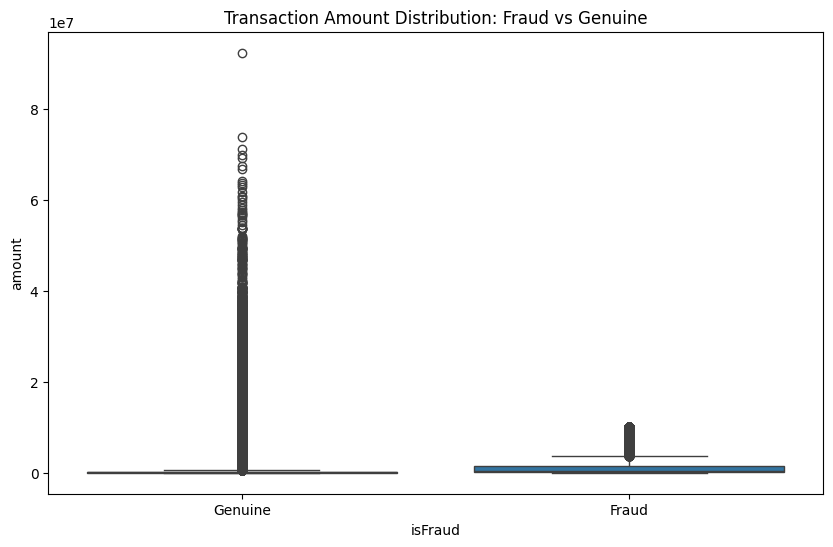

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df
)

plt.title("Transaction Amount Distribution: Fraud vs Genuine")

plt.xticks([0,1], ['Genuine', 'Fraud'])

plt.show()

In [19]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Investigating Balance Behavior - whether balance patterns differ for fraud

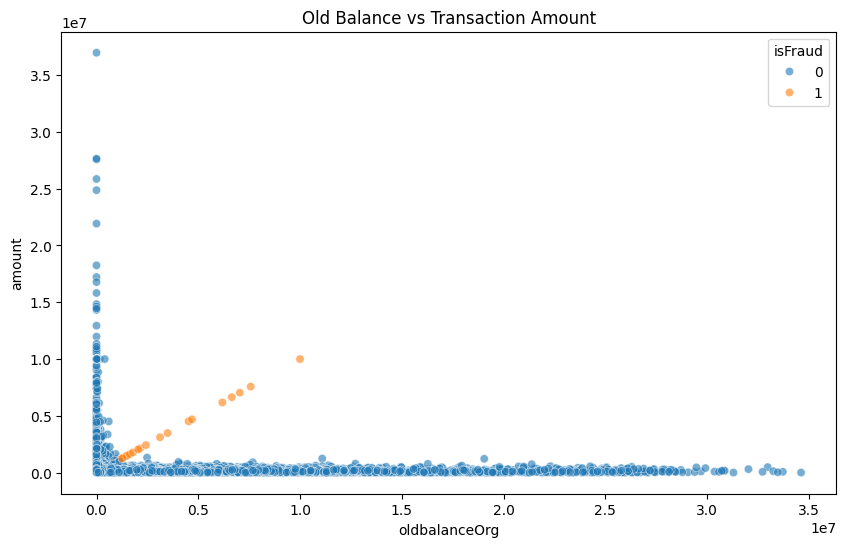

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='oldbalanceOrg',
    y='amount',
    hue='isFraud',
    data=df.sample(50000),
    alpha=0.6
)

plt.title("Old Balance vs Transaction Amount")

plt.show()

Transactions where the transfer amount closely matches the sender’s available balance should trigger additional fraud verification checks.

### Feature Engineering

In [21]:
df['balanceErrorOrig'] = (
    df['oldbalanceOrg']
    - df['newbalanceOrig']
    - df['amount']
)

In [22]:
df.groupby('isFraud')['balanceErrorOrig'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-201338.558109,606928.890826,-92445516.64,-249953.43,-69049.31,-3034.305,1.000000e-02
1,8213.0,-10692.325265,265146.131130,-10000000.00,0.00,0.00,0.000,3.725290e-09


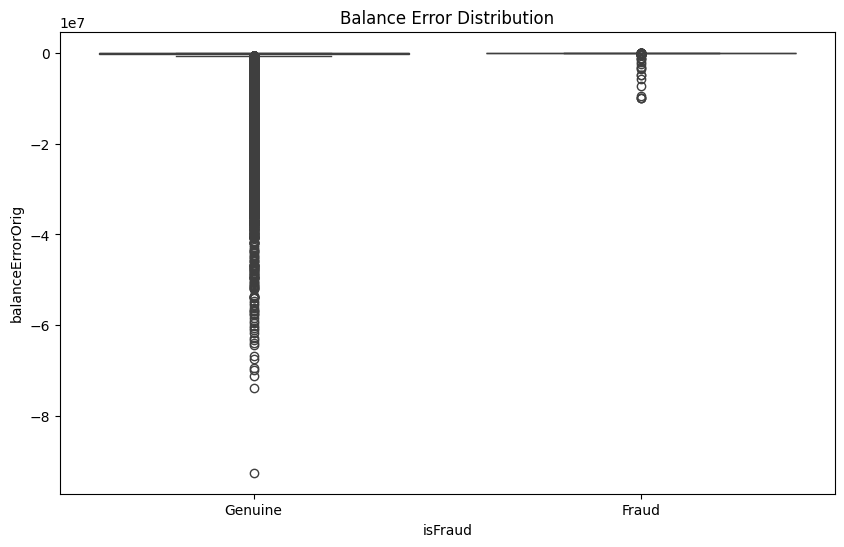

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='isFraud',
    y='balanceErrorOrig',
    data=df
)

plt.title("Balance Error Distribution")

plt.xticks([0,1], ['Genuine', 'Fraud'])

plt.show()

Destination Balance Error - whether destination accounts behave suspiciously

In [24]:
df['balanceErrorDest'] = (
    df['newbalanceDest']
    - df['oldbalanceDest']
    - df['amount']
)

In [25]:
df.groupby('isFraud')['balanceErrorDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-54692.231734,4.360026e+05,-13191233.98,-29259.805,-3500.68,0.0,75885725.63
1,8213.0,-732509.301069,1.867748e+06,-10000000.00,-442722.010,-2231.46,0.0,8875516.29


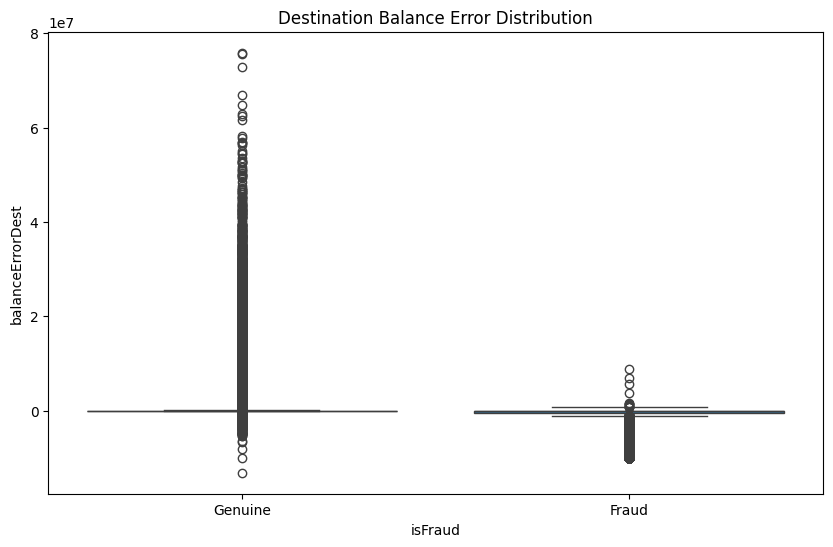

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='isFraud',
    y='balanceErrorDest',
    data=df
)

plt.title("Destination Balance Error Distribution")

plt.xticks([0,1], ['Genuine', 'Fraud'])

plt.show()

### ML pipeline preparation

Remove Identifier Columns

In [27]:
df.drop(
    ['nameOrig', 'nameDest'],
    axis=1,
    inplace=True
)

Encode Transaction Type

In [28]:
df = pd.get_dummies(
    df,
    columns=['type'],
    drop_first=True
)

Check Final Columns

In [29]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceErrorOrig,balanceErrorDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,1.455192e-11,-9839.64,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,-1.136868e-12,-1864.28,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,0.000000e+00,-181.00,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,0.000000e+00,-21363.00,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.000000e+00,-11668.14,False,False,True,False


In [30]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'balanceErrorOrig',
       'balanceErrorDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='str')

In [31]:
bool_columns = [
    'type_CASH_OUT',
    'type_DEBIT',
    'type_PAYMENT',
    'type_TRANSFER'
]

df[bool_columns] = df[bool_columns].astype(int)

In [32]:
df[bool_columns].head()

,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,0,0,1,0
1,0,0,1,0
2,0,0,0,1
3,1,0,0,0
4,0,0,1,0


In [33]:
df.to_csv(
    "D:\\R V Pavan\\Projects\\PayGuard AI\\Dataset\\cleaned_data.csv",
    index=False
)

Prepare Features and Target Variable

In [34]:
X = df.drop('isFraud', axis=1)

y = df['isFraud']

In [35]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (6362620, 13)
Target Shape: (6362620,)


In [36]:
y.value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Verify Shapes

In [39]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5090096, 13)
X_test : (1272524, 13)
y_train: (5090096,)
y_test : (1272524,)


Verify Fraud Distribution

In [40]:
print(y_train.value_counts(normalize=True) * 100)

print(y_test.value_counts(normalize=True) * 100)

isFraud
0    99.870926
1     0.129074
Name: proportion, dtype: float64
isFraud
0    99.870887
1     0.129113
Name: proportion, dtype: float64


### SMOTE — Handling Class Imbalance

In [41]:
from imblearn.over_sampling import SMOTE

In [42]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Verify New Distribution

In [43]:
print(y_train_smote.value_counts())

isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [44]:
print(y_train_smote.value_counts(normalize=True) * 100)

isFraud
0    50.0
1    50.0
Name: proportion, dtype: float64


### First ML Model — Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Generate Predictions

In [47]:
y_pred_lr = lr_model.predict(X_test)

Evaluate Model

In [48]:
from sklearn.metrics import classification_report

In [49]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.03      0.96      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.98   1272524



### Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Generate Predictions

In [52]:
y_pred_rf = rf_model.predict(X_test)

In [53]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



### Feature Importance Analysis - which features most influenced fraud prediction

In [54]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

Sort Features

In [55]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,balanceErrorOrig,0.416480
3,newbalanceOrig,0.177431
2,oldbalanceOrg,0.118686
1,amount,0.064434
11,type_PAYMENT,0.055074
12,type_TRANSFER,0.048268
8,balanceErrorDest,0.030803
9,type_CASH_OUT,0.027509
0,step,0.026392
5,newbalanceDest,0.019960


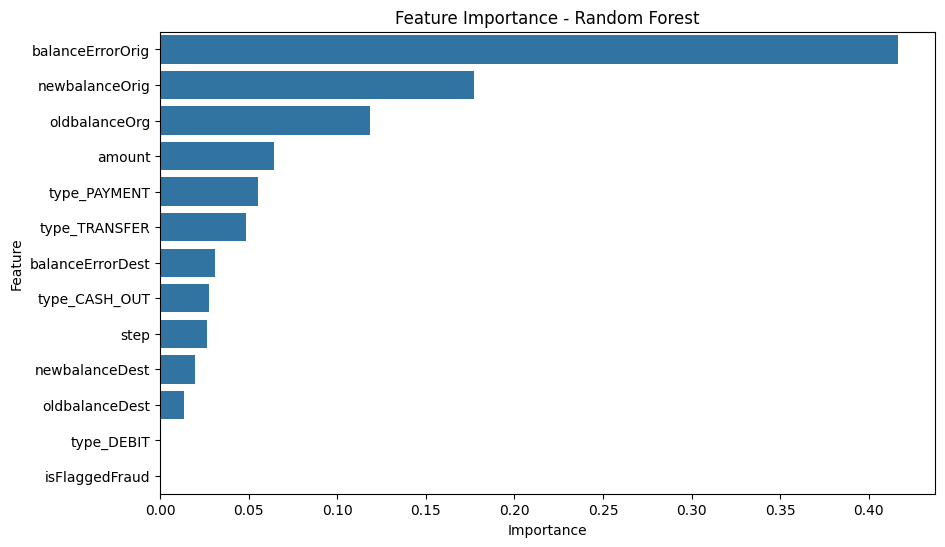

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

### Risk Scoring System

In [57]:
risk_scores = rf_model.predict_proba(X_test)[:,1]

Create Risk Score DataFrame

In [58]:
risk_df = X_test.copy()

risk_df['Actual_Fraud'] = y_test.values

risk_df['Risk_Score'] = risk_scores

Create Risk Levels

In [59]:
def assign_risk(score):

    if score >= 0.7:
        return "High"

    elif score >= 0.3:
        return "Medium"

    else:
        return "Low"

In [60]:
risk_df['Risk_Level'] = risk_df['Risk_Score'].apply(assign_risk)

In [61]:
risk_df[
    ['Risk_Score', 'Risk_Level', 'Actual_Fraud']
].head(20)

,Risk_Score,Risk_Level,Actual_Fraud
4051353,0.00,Low,0
5746321,0.00,Low,0
6361797,0.00,Low,0
2247309,0.00,Low,0
4692207,0.00,Low,0
4627047,0.00,Low,0
4291699,0.12,Low,0
3212826,0.00,Low,0
5830602,0.00,Low,0
2403731,0.00,Low,0


In [62]:
risk_df['Risk_Level'].value_counts()

Risk_Level
Low       1270803
High         1654
Medium         67
Name: count, dtype: int64

### Actual suspicious transactions

In [63]:
high_risk_transactions = risk_df[
    risk_df['Risk_Level'] == 'High'
]

In [64]:
high_risk_transactions[
    ['Risk_Score', 'Risk_Level', 'Actual_Fraud']
].head(20)

,Risk_Score,Risk_Level,Actual_Fraud
6202693,1.00,High,1
355226,0.77,High,0
555101,1.00,High,1
49825,0.94,High,1
819544,0.97,High,1
6010938,1.00,High,1
6308248,1.00,High,1
6116735,1.00,High,1
6362596,1.00,High,1
6281496,1.00,High,1


In [65]:
high_risk_transactions['Actual_Fraud'].value_counts()

Actual_Fraud
1    1639
0      15
Name: count, dtype: int64

Export Final Risk Dataset

In [66]:
risk_df.to_csv(
    "D:\\R V Pavan\\Projects\\PayGuard AI\\Output\\risk_scored_transactions.csv",
    index=False
)

Correction for dashboard

In [67]:
def get_transaction_type(row):

    if row['type_CASH_OUT'] == 1:
        return 'CASH_OUT'

    elif row['type_DEBIT'] == 1:
        return 'DEBIT'

    elif row['type_PAYMENT'] == 1:
        return 'PAYMENT'

    elif row['type_TRANSFER'] == 1:
        return 'TRANSFER'

    else:
        return 'CASH_IN'

In [68]:
risk_df['Transaction_Type'] = risk_df.apply(
    get_transaction_type,
    axis=1
)

In [69]:
risk_df[
    ['Transaction_Type']
].head()

,Transaction_Type
4051353,TRANSFER
5746321,CASH_IN
6361797,PAYMENT
2247309,CASH_OUT
4692207,CASH_OUT


In [71]:
risk_df.to_csv(
    "D:\\R V Pavan\\Projects\\PayGuard AI\\Output\\risk_scored_transactions.csv",
    index=False
)

In [72]:
feature_importance.to_csv(
    "D:\\R V Pavan\\Projects\\PayGuard AI\\Output\\feature_importance.csv",
    index=False
)